In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/sayyar222/dataset/Salary_Data.csv")

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [6]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [7]:
df[["YearsExperience"]]

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

LinearRegression()

In [11]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9423.815323030976
Intercept: 25321.583011776813


In [12]:
print(
    f"Salary = {model.coef_[0]:.2f} × YearsExperience + {model.intercept_:.2f}"
)

Salary = 9423.82 × YearsExperience + 25321.58


In [13]:
y_pred = model.predict(X_test)

In [14]:
results = pd.DataFrame({
    "YearsExperience": X_test["YearsExperience"],
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

print(results)

    YearsExperience  Actual Salary  Predicted Salary
27              9.6       112635.0     115790.210113
15              4.9        67938.0      71498.278095
23              8.2       113812.0     102596.868661
17              5.3        83088.0      75267.804224
8               3.2        64445.0      55477.792045
9               3.7        57189.0      60189.699707


In [15]:
new_data = [[5.0]]

prediction = model.predict(new_data)

print("Predicted Salary:", prediction[0])

Predicted Salary: 72440.6596269317


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 49830096.85590839
R2 Score: 0.9024461774180497


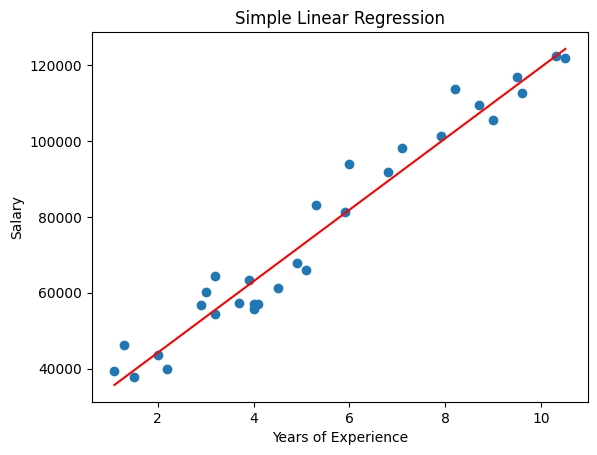

In [17]:
plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
    color="red"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")

plt.show()